## Access Radar Rottnestshelf Velocity Hourly Averaged Realtime Non QC (Zarr)
This Jupyter notebook demonstrates how to access and plot radar_RottnestShelf_velocity_hourly_averaged_realtime_nonqc data, available as a [Zarr](https://zarr.dev/) dataset stored on S3.

🔗 More information about the dataset is available [in the AODN metadata catalogue](https://catalogue-imos.aodn.org.au/geonetwork/srv/eng/catalog.search#/metadata/8b469535-eb48-4f1f-9612-bdf2e83cdce8).

📌 The source of truth for this notebook is maintained on [GitHub](https://github.com/aodn/aodn_cloud_optimised/tree/main/notebooks/radar_RottnestShelf_velocity_hourly_averaged_realtime_nonqc.ipynb).


In [1]:
dataset_name = "radar_RottnestShelf_velocity_hourly_averaged_realtime_nonqc"

## Install/Update packages and Load common functions

In [2]:
import os, requests, importlib.util

open('setup.py', 'w').write(requests.get('https://raw.githubusercontent.com/aodn/aodn_cloud_optimised/main/notebooks/setup.py').text)

spec = importlib.util.spec_from_file_location("setup", "setup.py")
setup = importlib.util.module_from_spec(spec)
spec.loader.exec_module(setup)

setup.install_requirements()
setup.load_dataquery()

✅ Virtual environment already exists, skipping creation.


Using Python 3.12.6 environment at: /home/lbesnard/github_repo/aodn_cloud_optimised/.venv
Resolved 155 packages in 58ms
Checked 155 packages in 1ms


✅ Local version 0.3.11 is up to date (remote: 0.3.11)


In [3]:
from DataQuery import GetAodn

/home/lbesnard/github_repo/aodn_cloud_optimised/notebooks/DataQuery.py:4001: UserWarning: registration of accessor <class 'DataQuery.AODNAccessor'> under name 'aodn' for type <class 'pandas.core.frame.DataFrame'> is overriding a preexisting attribute with the same name.
  @pd.api.extensions.register_dataframe_accessor("aodn")


# Understanding the Dataset

In [4]:
# remote zarr dataset
aodn = GetAodn()
dname = f'{dataset_name}.zarr'
%time aodn_dataset = aodn.get_dataset(dname)

CPU times: user 377 ms, sys: 43.2 ms, total: 420 ms
Wall time: 942 ms


In [5]:
ds = aodn_dataset.zarr_store
ds.info()

xarray.Dataset {
dimensions:
	TIME = 78905 ;
	LATITUDE = 92 ;
	LONGITUDE = 62 ;

variables:
	float64 GDOP(TIME, LATITUDE, LONGITUDE) ;
		GDOP:comment = This angle is used to assess the impact of Geometric Dilution of Precision. If angle between [150; 160[ or ]20; 30], QC flag will not be lower than 3. If angle >= 160 or <= 20, then QC flag will not be lower than 4. ;
		GDOP:long_name = radar beam intersection angle ;
		GDOP:units = Degrees ;
		GDOP:valid_max = 180.0 ;
		GDOP:valid_min = 0.0 ;
	float64 LATITUDE(LATITUDE) ;
		LATITUDE:axis = Y ;
		LATITUDE:long_name = latitude ;
		LATITUDE:reference_datum = geographical coordinates, WGS84 datum ;
		LATITUDE:standard_name = latitude ;
		LATITUDE:units = degrees_north ;
		LATITUDE:valid_max = 90.0 ;
		LATITUDE:valid_min = -90.0 ;
	float64 LONGITUDE(LONGITUDE) ;
		LONGITUDE:axis = X ;
		LONGITUDE:long_name = longitude ;
		LONGITUDE:reference_datum = geographical coordinates, WGS84 datum ;
		LONGITUDE:standard_name = longitude ;
		LONGITUDE:

## Plot time coverage

In [6]:
aodn_dataset.get_temporal_extent()

(Timestamp('2010-03-10 12:30:00'), Timestamp('2026-04-14 01:00:00.000007168'))

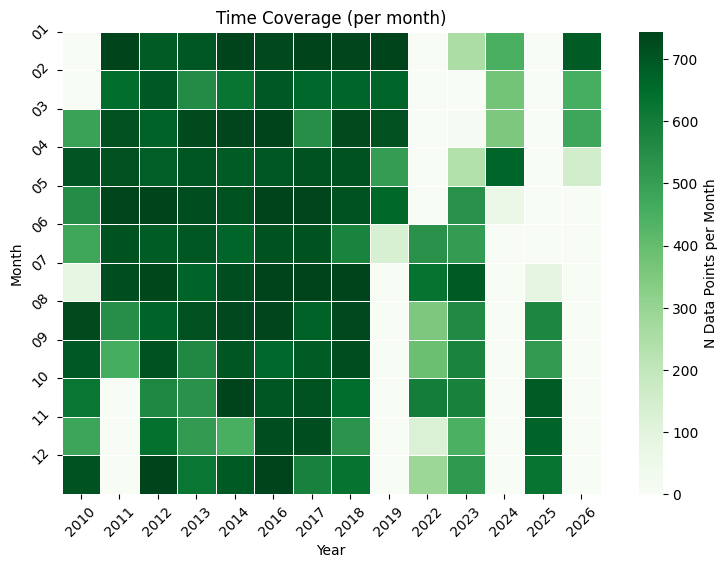

In [7]:
aodn_dataset.plot_time_coverage()

## Plot a gridded variable

/home/lbesnard/github_repo/aodn_cloud_optimised/notebooks/DataQuery.py:1143: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])  # Leave space for the colorbar


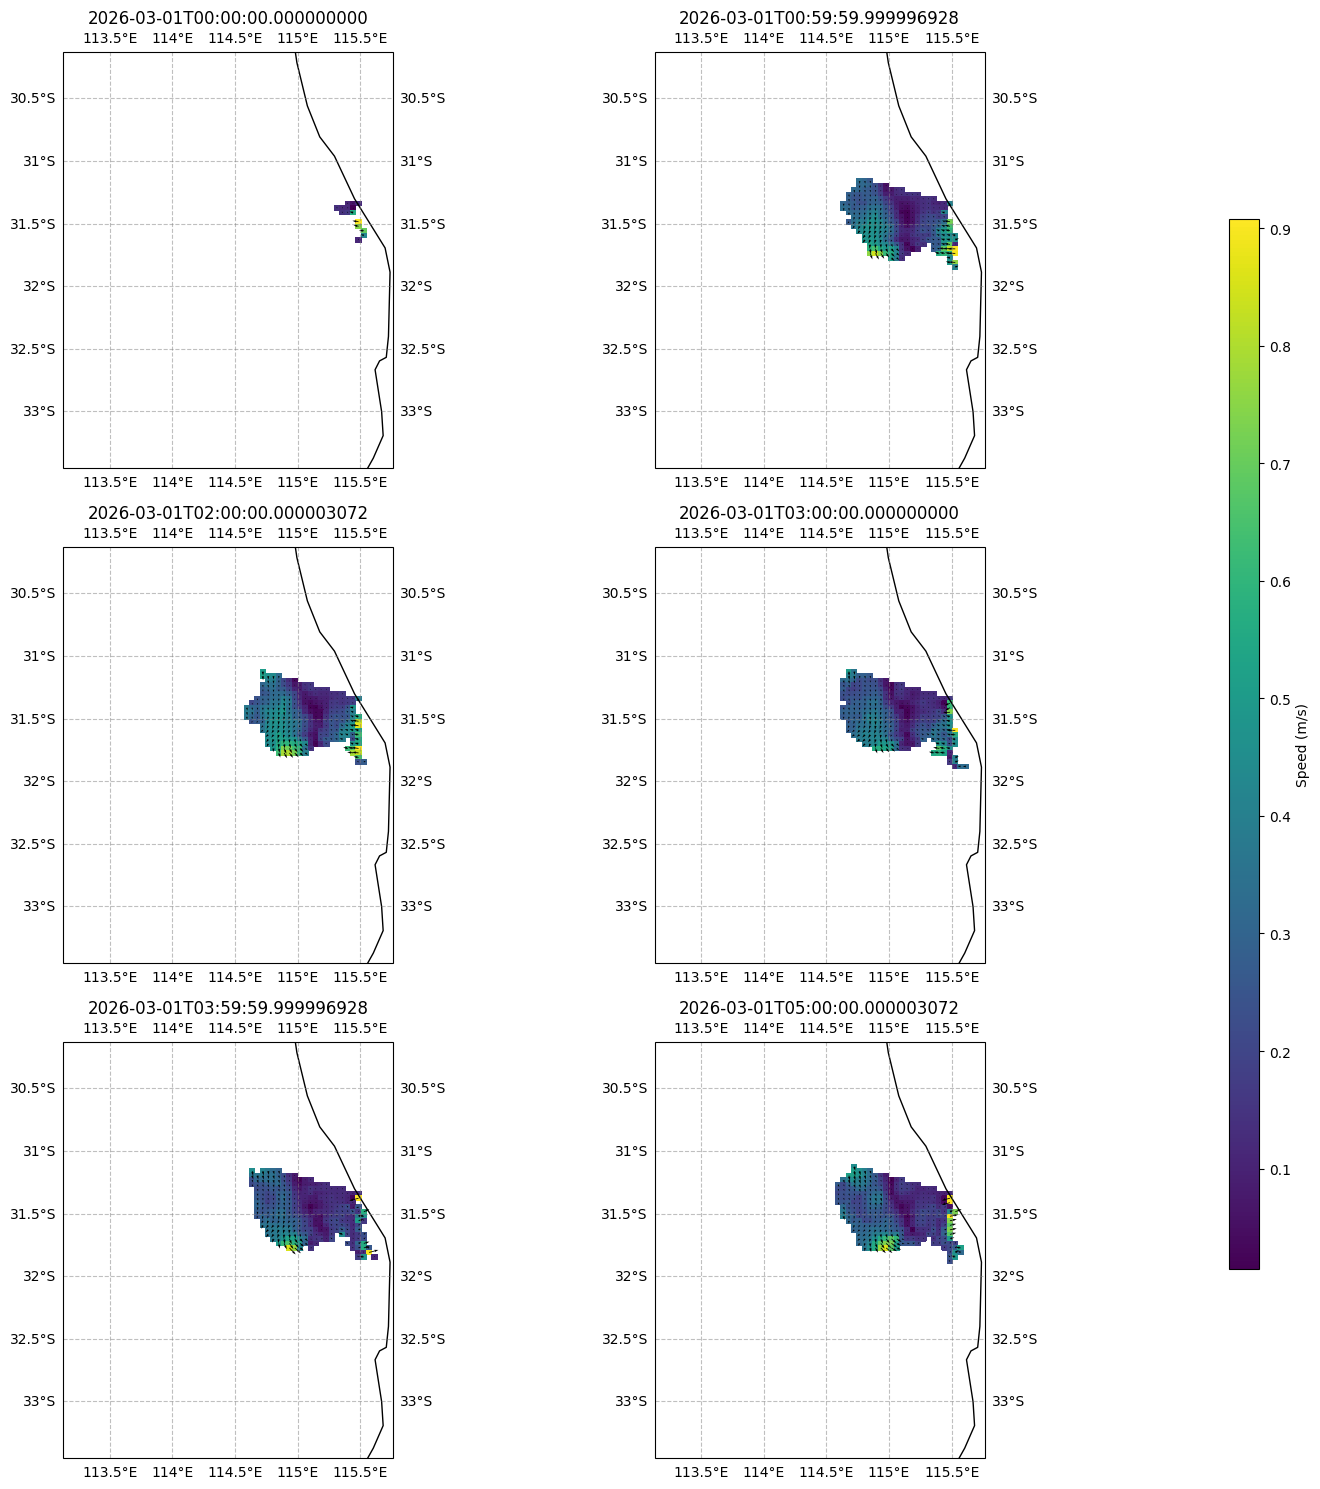

In [8]:
aodn_dataset.plot_radar_water_velocity_gridded(date_start='2026-03-01T00:00:00')

<Figure size 800x800 with 0 Axes>

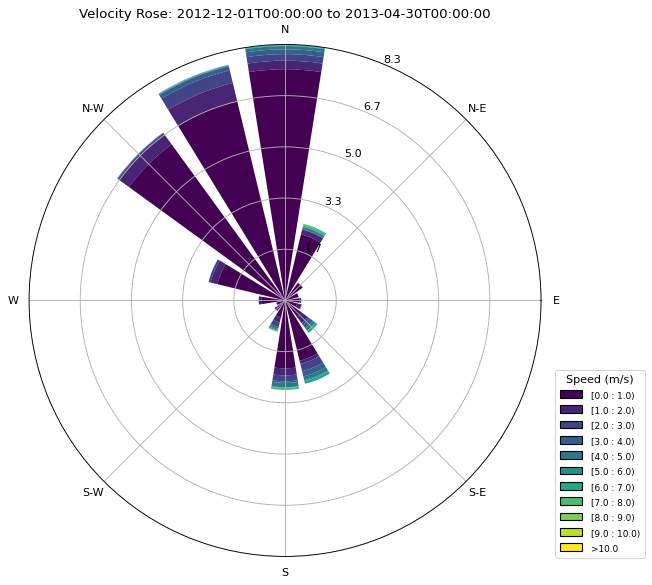

CPU times: user 1.17 s, sys: 420 ms, total: 1.59 s
Wall time: 2.02 s


In [9]:
%%time
aodn_dataset.plot_radar_water_velocity_rose(date_start='2012-12-01T00:00:00', 
                                            date_end='2013-04-30T00:00:00')

Using highest-density point: -31.882°, 115.317°


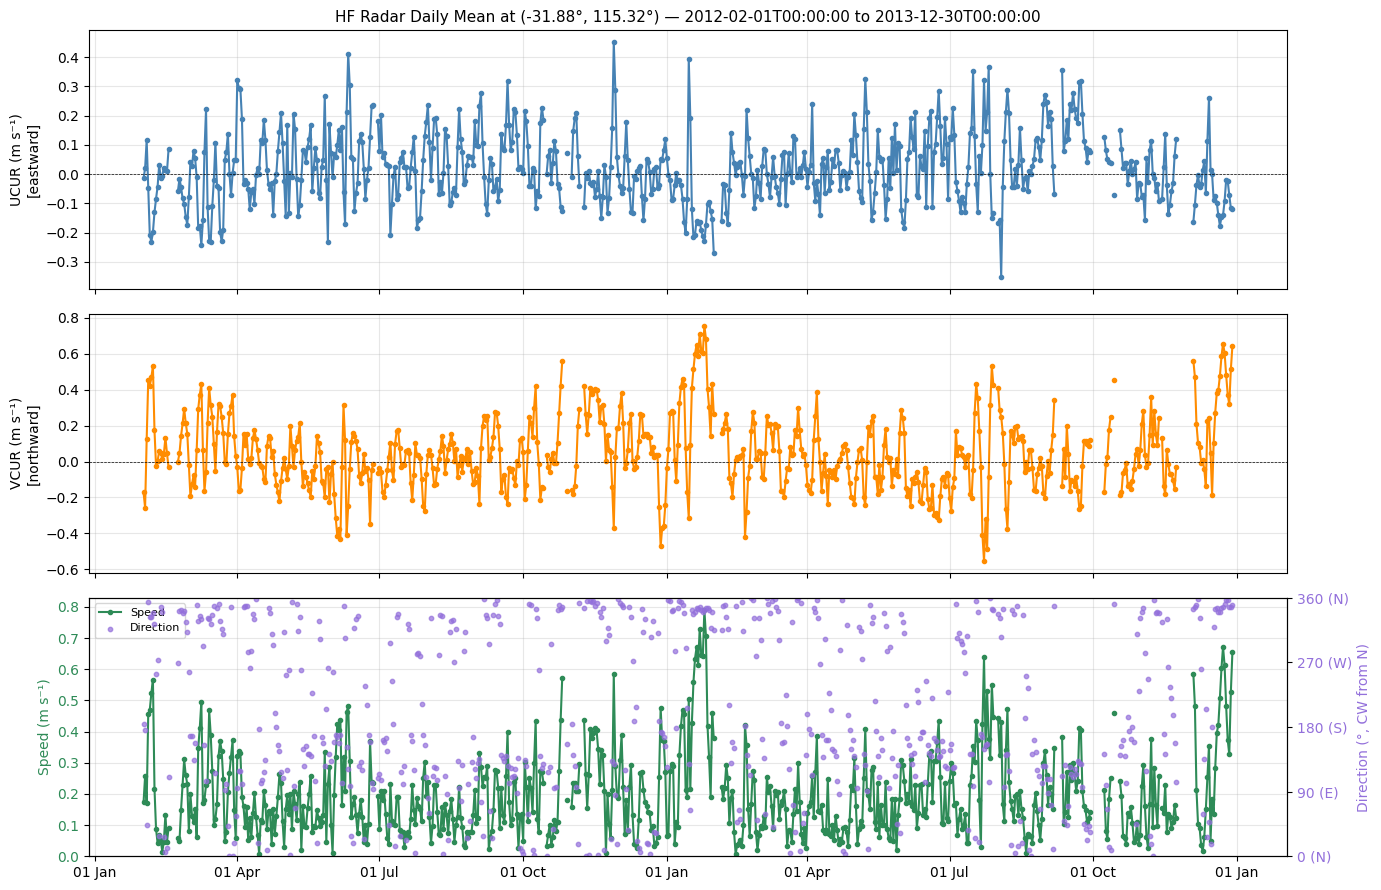

CPU times: user 3.1 s, sys: 584 ms, total: 3.69 s
Wall time: 6.04 s


,u,v,speed,direction
TIME,,,,
2012-02-01,-0.014579,-0.172016,0.172633,184.844534
2012-02-02,0.020219,-0.256221,0.257017,175.487979
2012-02-03,0.116289,0.123474,0.169614,43.283544
2012-02-04,-0.048522,0.453181,0.455771,353.888670
2012-02-05,-0.208429,0.421215,0.469962,333.672543
...,...,...,...,...
2013-12-25,-0.019335,0.481147,0.481535,357.698834
2013-12-26,-0.023552,0.372198,0.372942,356.379203
2013-12-27,-0.072040,0.318874,0.326911,347.269490


In [10]:
%%time
aodn_dataset.plot_radar_water_velocity_timeseries(date_start='2012-02-01T00:00:00', 
                                            date_end='2013-12-30T00:00:00')